# Demo: Controlled Pendulum System
## Verification Co-Simulation Algorithms

In [1]:
import sys
import numpy as np
from pathlib import Path
import time
import scipy
from OMPython import ModelicaSystem

repo_root = Path.cwd().parent.parent
sys.path.insert(0, str(repo_root))
from docs.plot_setup import set_professional_style
plt = set_professional_style()

from SysSimX.utilities.update_fmus import get_fmu_paths
from SysSimX.components.fmu_comp import FMUComponent
from SysSimX.system.connection import Connection
from SysSimX.system.system import System
from SysSimX.viz.sysgraph import SystemGraphVisualizer

### **1. General Simulation Setup**

In [2]:
t0 = 0
dt_values = [0.02, 0.01, 0.005, 0.001]
t_end = 0.5

### **2. Monolithic Model - Reference Solution**

- The monolithic Modelica model for the controlled pendulum system is used as reference solution for the verification of the co-simulation algorithms.
- The system model is monolithical because in Modelica, all subsystems are white box models and all involved euqations, including algebraic equations, are solved simultaneously by the Modelica solver DASSL.
- The simple model has no strong algebraic coupling. There is a torque connection (drive to pendulum) and angular velocity connection (pendulum to drive) between the drive and pendulum subsystems.



In [3]:
# 1) Build the Modelica Model
pkg_dir_path = Path.cwd() / 'MyModels/Modelica/ControlledPendulum'
pkg_file_path = pkg_dir_path / 'package.mo'

models = ('ControlledPendulum.Demo_Driven', 'ControlledPendulum.Demo_Driven_Coupled')
cases = ('simple', 'complex')

dt_monolithic = 1e-4
solver_tolerance = 1e-8
solver_monolithic = 'dassl'

ref_res = {}
for model, case in zip(models, cases):
    print(60 * "=")
    print(f'Starting Monolithic Simulation - Type: {case}')
    print(60 * "=")

    # 1) Create Modelica System Model
    model = ModelicaSystem(str(pkg_file_path), model)
    
    # 2) Set Simulation Options, Build and Simulate
    simulation_options = [
        f"startTime={t0}",
        f"stopTime={t_end}",        
        f"stepSize={dt_monolithic}",
        f"tolerance={solver_tolerance}",
        f"solver={solver_monolithic}"
        ]
    #model.setOptimizationOptions(f"numberOfIntervals={int(t_end/dt_monolithic)}")
    model.setSimulationOptions(simulation_options)
    model.buildModel()

    start_time = time.time()

    model.simulate()

    # 3) Extract and Save Results
    solutions_dict = {}
    solutions = model.getSolutions()
    for sol in solutions:
        solutions_dict[sol] = model.getSolutions(sol)
    end_time = time.time()
    ref_res[case] = solutions_dict

    # 4) Save Results to .mat file
    res_file = Path.cwd() / f'results/monolithic_{case}.mat'
    scipy.io.savemat(str(res_file), solutions_dict, long_field_names=True)

    print(f'Monolithic Simulation Completed in {end_time - start_time:.2f} seconds.')

Starting Monolithic Simulation - Type: simple

Notification: Automatically loaded package Complex 4.0.0 due to uses annotation from Modelica.
Notification: Automatically loaded package ModelicaServices 4.0.0 due to uses annotation from Modelica.
Notification: Automatically loaded package Modelica 4.0.0 due to usage.


LOG_SUCCESS       | info    | The initialization finished successfully without homotopy method.
LOG_SUCCESS       | info    | The simulation finished successfully.


KeyboardInterrupt: 

In [ ]:
for case in ref_res:
    for key in ref_res[case]:
        if isinstance(ref_res[case][key], np.ndarray):
            ref_res[case][key] = ref_res[case][key].flatten()

t_simple = ref_res['simple']['time']
t_complex = ref_res['complex']['time']

q_ref = ref_res['simple']['reference.q_ref']

theta_simple = ref_res['simple']['pendulum.q']
theta_complex = ref_res['complex']['pendulum.q']

omega_simple = ref_res['simple']['pendulum.omega']
omega_complex = ref_res['complex']['pendulum.omega']

alpha_simple = ref_res['simple']['pendulum.alpha']
alpha_complex = ref_res['complex']['pendulum.alpha']

torque_simple = ref_res['simple']['drive.torque']
torque_complex = ref_res['complex']['drive.torque']

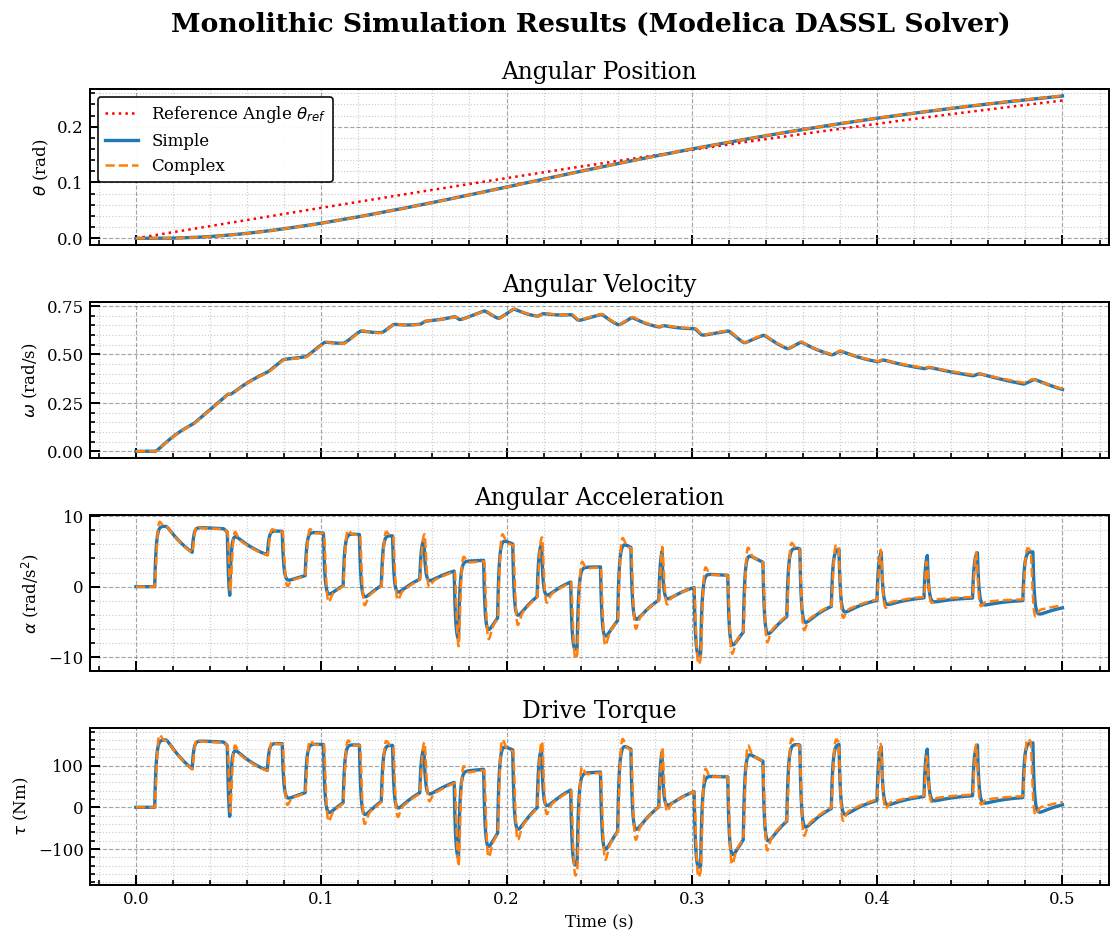

In [ ]:
style_simple = {'color': 'tab:blue', 'linestyle': '-', 'label': 'Simple', 'linewidth': 2}
style_complex = {'color': 'tab:orange', 'linestyle': '--', 'label': 'Complex', 'linewidth': 1.5}

fig, axs = plt.subplots(4, 1, figsize=(10, 8), sharex=True)

fig.suptitle('Monolithic Simulation Results (Modelica DASSL Solver)', fontsize=16, fontweight='bold')

axs[0].set_title(r'Angular Position')
axs[0].plot(t_simple, q_ref, label=r'Reference Angle $\theta_{ref}$', color='red', linestyle=':', linewidth=1.5)
axs[0].plot(t_simple, theta_simple, **style_simple)
axs[0].plot(t_complex, theta_complex, **style_complex)
axs[0].set_ylabel(r'$\theta$ (rad)')
axs[0].legend(fontsize=10)

axs[1].set_title(r'Angular Velocity')
axs[1].plot(t_simple, omega_simple, **style_simple)
axs[1].plot(t_complex, omega_complex, **style_complex)
axs[1].set_ylabel(r'$\omega$ (rad/s)')

axs[2].set_title(r'Angular Acceleration')
axs[2].plot(t_simple, alpha_simple, **style_simple)
axs[2].plot(t_complex, alpha_complex, **style_complex)
axs[2].set_ylabel(r'$\alpha$ (rad/s$^2$)')

axs[3].set_title(r'Drive Torque')
axs[3].plot(t_simple, torque_simple, **style_simple)
axs[3].plot(t_complex, torque_complex, **style_complex)
axs[3].set_ylabel(r'$\tau$ (Nm)')
axs[3].set_xlabel('Time (s)')

for ax in axs:
    ax.minorticks_on()
    ax.grid(True, which='major', linestyle='--', alpha=0.7)
    ax.grid(True, which='minor', linestyle=':', alpha=0.4)


# adjust layout and add vertical space
plt.tight_layout(rect=[0, 0, 0.95, 0.95])
plt.subplots_adjust(top=0.9)
plt.savefig("figures/reference_monolithic.svg")
plt.show()

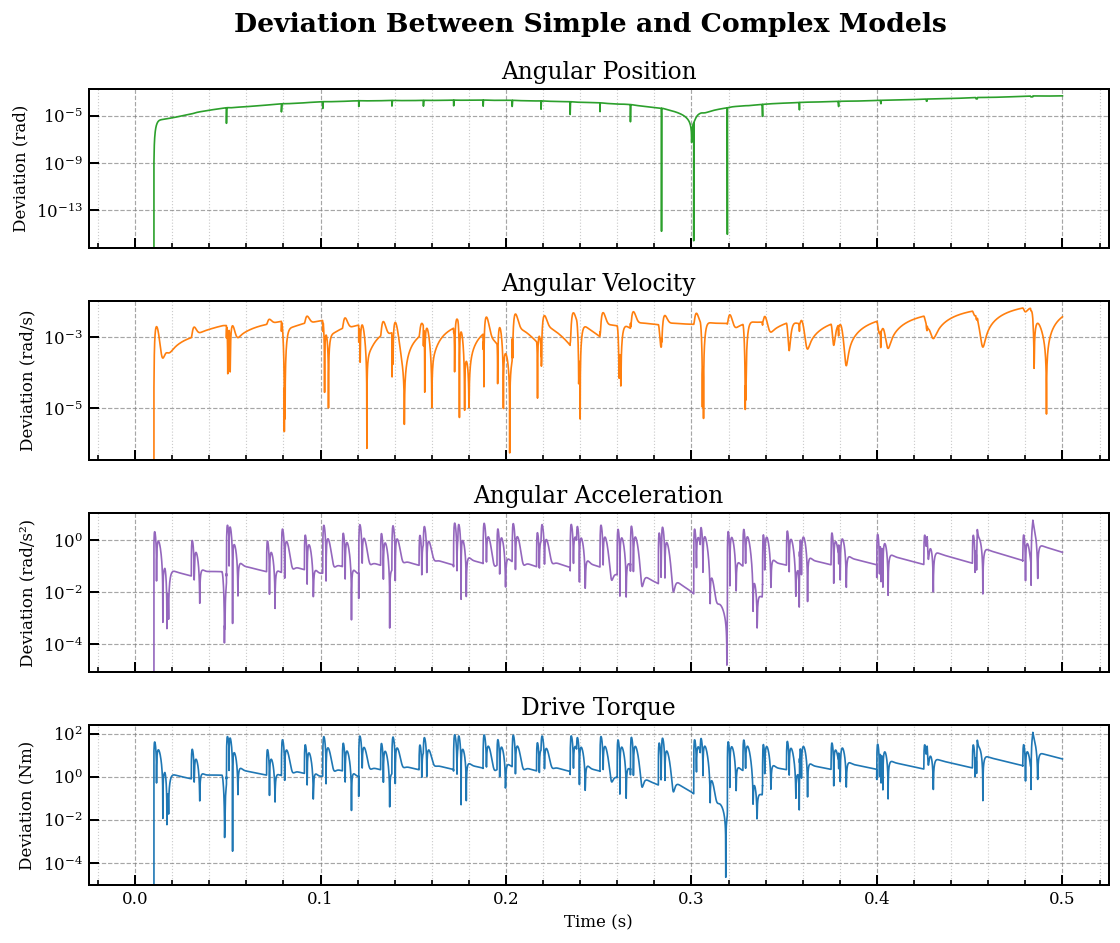

In [ ]:
# Claculate relative deviation between both models
eps = 1e-10
theta_diff = np.abs(theta_simple - theta_complex) 
omega_diff = np.abs(omega_simple - omega_complex) 
alpha_diff = np.abs(alpha_simple - alpha_complex) 
torque_diff = np.abs(torque_simple - torque_complex)

fig, axs = plt.subplots(4, 1, figsize=(10, 8), sharex=True)
fig.suptitle('Deviation Between Simple and Complex Models', fontsize=16, fontweight='bold')
axs[0].set_title(r'Angular Position')
axs[0].semilogy(t_simple, theta_diff, color='tab:green', linestyle='-', linewidth=1)
axs[0].set_ylabel(r'Deviation (rad)', fontsize=10)

axs[1].set_title(r'Angular Velocity')
axs[1].semilogy(t_simple, omega_diff, color='tab:orange', linestyle='-', linewidth=1)
axs[1].set_ylabel(r'Deviation (rad/s)', fontsize=10)

axs[2].set_title(r'Angular Acceleration')
axs[2].semilogy(t_simple, alpha_diff, color='tab:purple', linestyle='-', linewidth=1)
axs[2].set_ylabel(r'Deviation (rad/s²)', fontsize=10)
    
axs[3].set_title(r'Drive Torque')
axs[3].semilogy(t_simple, torque_diff, color='tab:blue', linestyle='-', linewidth=1)
axs[3].set_ylabel(r'Deviation (Nm)', fontsize=10)
axs[3].set_xlabel('Time (s)', fontsize=10)

for ax in axs:
    ax.minorticks_on()
    ax.grid(True, which='major', linestyle='--', alpha=0.7)
    ax.grid(True, which='minor', linestyle=':', alpha=0.4)

# adjust layout and add vertical space
plt.tight_layout(rect=[0, 0, 0.95, 0.95])
plt.subplots_adjust(top=0.9)
plt.show()




### **3. SysSimX Co-Simulation Algorithms**

In [ ]:
algorithms = ('Jacobi', 'Gauss-Seidel', 'IJCSA')

#### **3.1 Generate FMUComponents**

In [ ]:
demo_dir_path = Path(repo_root / 'demos' / 'ControlledPendulum')
package_path = Path.cwd() / 'MyModels/Modelica/ControlledPendulum/'
fmu_output_dir = Path.cwd() / 'MyModels/FMUs/'
fmu_paths = get_fmu_paths(package_path, fmu_output_dir, force_rebuild=True)

print(60 * "=")
print('FMU Paths:')
for name, path in fmu_paths.items():
    print(f'  {name}: {path}')
print(60 * "=")

ref           = FMUComponent(name='ref', fmu_path=fmu_paths['Reference'], group='Reference')
sensor_ref    = FMUComponent(name='sensor_ref', fmu_path=fmu_paths['AngleEncoder'], group='Sensors')
sensor_state  = FMUComponent(name='sensor_state', fmu_path=fmu_paths['AngleEncoder'], group='Sensors')
pid           = FMUComponent(name='pid', fmu_path=fmu_paths['PID_Continuous'], group='Control')
drive         = FMUComponent(name='drive', fmu_path=fmu_paths['Drive'], group='Actuator')
drive_coupled = FMUComponent(name='drive_coupled', fmu_path=fmu_paths['Drive_Coupled'], group='Actuator')
pendulum      = FMUComponent(name='pendulum', fmu_path=fmu_paths['Pendulum'], group='Plant')

################################################################################
Processing model: ControlledPendulum.AngleEncoder

Notification: Automatically loaded package Complex 4.0.0 due to uses annotation from Modelica.
Notification: Automatically loaded package ModelicaServices 4.0.0 due to uses annotation from Modelica.
Notification: Automatically loaded package Modelica 4.0.0 due to usage.


FMU for ControlledPendulum.AngleEncoder moved to:
/home/flo/code/SystemSimulation/demos/ControlledPendulum/MyModels/FMUs/AngleEncoder.fmu

################################################################################
Processing model: ControlledPendulum.Demo_Driven

Notification: Automatically loaded package Complex 4.0.0 due to uses annotation from Modelica.
Notification: Automatically loaded package ModelicaServices 4.0.0 due to uses annotation from Modelica.
Notification: Automatically loaded package Modelica 4.0.0 due to usage.


FMU for ControlledPendulum.Demo_Driven moved to:
/ho

#### **3.2 Simple Coupled Co-Simulation: FMU as Force Element***

##### **3.2.1 Drive Subsystem FMU as Force Element**
- In this system configuration, the controlled pendulum subsystem is modeled and the **drive subsystem FMU is used as a force element acting on the pendulum**.
- The drive FMU provides the torque input on the pendulum based on the control signal $u_{controle}$ from the PID controller and the angular velocity $\omega_{pendulum}$ of the pendulum.
- The drive behavior is described by the following equations:

$$\begin{align*}
U &= U_M \cdot u_{control} \\
\omega_M &= i_M \cdot \omega_{pendulum} \\
E &= k_e \cdot \omega_M \\
\frac{dI}{dt} &= \frac{1}{L_M} \cdot (U - E - R_M \cdot I) \\
T_{drive} &= \eta_M \cdot i_M \cdot k_M \cdot I
\end{align*}$$

where:
- $U$: Voltage applied to the motor
- $U_M$: Maximum voltage
- $u_{control}$: Control signal from PID controller
- $\omega_M$: Motor angular velocity
- $i_M$: Gear ratio
- $\omega_{pendulum}$: Pendulum angular velocity
- $E$: Back electromotive voltage
- $k_e$: Back EMF constant
- $I$: Armature current
- $L_M$: Motor inductance
- $R_M$: Armature resistance
- $T_{drive}$: Torque applied to the pendulum
- $\eta_M$: Motor efficiency
- $k_M$: Motor torque constant



##### **3.2.2 Pendulum Subsystem**

- The pendulum subsystem receives the **torque $T_{drive}$ as input** from the drive FMU
- The pendulum computes its **angular position $\theta_{pendulum}$ and angular velocity $\omega_{pendulum}$ as outputs** based on the applied torque and its own dynamics.
- The pendulum behavior is described by the following equations:
$$\begin{align*}
\frac{d\theta_{pendulum}}{dt} &= \omega_{pendulum} \\
\frac{d\omega_{pendulum}}{dt} &= -\frac{m \cdot g \cdot L}{I} \cdot \sin(\theta_{pendulum}) + \frac{T_{drive}}{I}
\end{align*}$$

where:
- $\theta_{pendulum}$: Pendulum angular position
- $\omega_{pendulum}$: Pendulum angular velocity
- $m$: Mass of the pendulum
- $g$: Gravitational acceleration
- $L$: Length of the pendulum (effective moment arm for gravitational torque)
- $I$: Moment of inertia of the pendulum


##### **3.2.3 Structural Dependencies**

**Drive FMU as Force Element:**
- The torque output $T_{drive}$ from the drive FMU depends directly only on the internal state $I$ and internal parameters of the drive FMU.
- The derivative of the state $\frac{dI}{dt}$ depends on the input variables $u_{control}$ and $\omega_{pendulum}$.
- There is no direct algebraic loop between the drive FMU and the pendulum subsystem, as the torque output does not depend algebraically on the current angular velocity $\omega_{pendulum}$

**Pendulum Subsystem:**
- The angular position $\theta_{pendulum}$ and angular velocity $\omega_{pendulum}$ depend directly only on their own internal states and have no other input dependencies.
- The derivative of the angular velocity $\frac{d\omega_{pendulum}}{dt}$ depends on the input torque $T_{drive}$ from the drive FMU.
- Since output variables of the pendulum subsystem do not have input dependencies on the drive FMU, there is no direct algebraic loop between the pendulum subsystem and the drive FMU.

Execution Order (generations):
['pendulum', 'ref']
['sensor_ref', 'sensor_state']
['pid']
['drive']

Algebraic Loops:


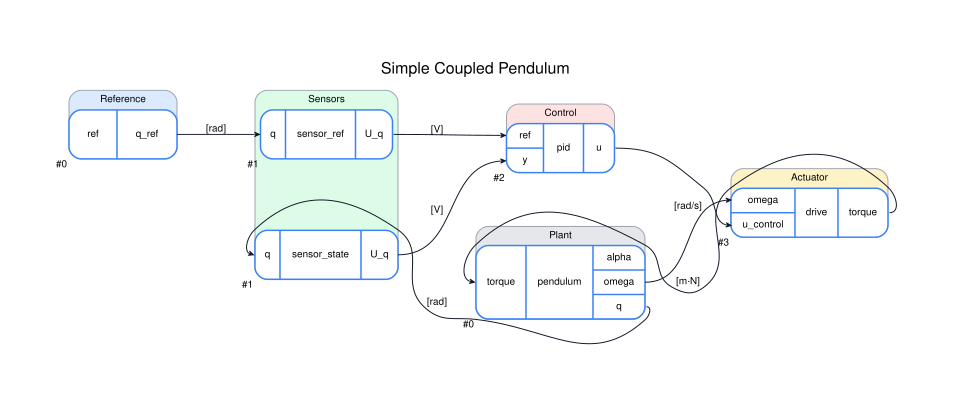

Simulating Simple Coupled System with Jacobi and dt=0.02...
LOG_SOLVER        | info    | CVODE linear multistep method CV_BDF
LOG_SOLVER        | info    | CVODE maximum integration order CV_ITER_NEWTON
LOG_SOLVER        | info    | CVODE use equidistant time grid YES
LOG_SOLVER        | info    | CVODE Using relative error tolerance 1.000000e-06
LOG_SOLVER        | info    | CVODE Using dense internal linear solver SUNLinSol_Dense.
LOG_SOLVER        | info    | CVODE Use internal dense numeric jacobian method.
LOG_SOLVER        | info    | CVODE uses internal root finding method NO
LOG_SOLVER        | info    | CVODE maximum absolut step size 0
LOG_SOLVER        | info    | CVODE initial step size is set automatically
LOG_SOLVER        | info    | CVODE maximum integration order 5
LOG_SOLVER        | info    | CVODE maximum number of nonlinear convergence failures permitted during one step 10
LOG_SOLVER        | info    | CVODE BDF stability limit detection algorithm OFF
LOG_SOLVER  

In [ ]:
c1 = Connection(src_comp=ref.name, src_port=ref.output_specs['q_ref'].name,
                dst_comp=sensor_ref.name, dst_port=sensor_ref.input_specs['q'].name)

c2 = Connection(src_comp=pendulum.name, src_port=pendulum.output_specs['q'].name,
                dst_comp=sensor_state.name, dst_port=sensor_state.input_specs['q'].name)

c3 = Connection(src_comp=sensor_ref.name, src_port=sensor_ref.output_specs['U_q'].name,
                dst_comp=pid.name, dst_port=pid.input_specs['ref'].name)

c4 = Connection(src_comp=sensor_state.name, src_port=sensor_state.output_specs['U_q'].name,
                dst_comp=pid.name, dst_port=pid.input_specs['y'].name)

c5 = Connection(src_comp=pid.name, src_port=pid.output_specs['u'].name,
                dst_comp=drive.name, dst_port=drive.input_specs['u_control'].name)

c6 = Connection(src_comp=drive.name, src_port=drive.output_specs['torque'].name,
                dst_comp=pendulum.name, dst_port=pendulum.input_specs['torque'].name)

c7 = Connection(src_comp=pendulum.name, src_port=pendulum.output_specs['omega'].name,
                dst_comp=drive.name, dst_port=drive.input_specs['omega'].name)

connections = [c1, c2, c3, c4, c5, c6, c7]
components = [ref, sensor_ref, sensor_state, pid, drive, pendulum]

system = System(name="Simple Coupled Pendulum")
for comp in components:
    system.add_component(comp)
for conn in connections:
    system.add_connection(conn)

simple_system = system
simple_system.compute_execution_order()

print("Execution Order (generations):")
for gen in simple_system.execution_order:
    print(gen)

print("\nAlgebraic Loops:")
for loop in simple_system.algebraic_loops:
    print(loop)

visualizer = SystemGraphVisualizer(simple_system)
visualizer.visualize()
visualizer.save("figures/ControlledPendulumSimple.svg")

# Run simulations for different algorithms and time steps
results = {}
res_dir = Path.cwd() / 'results/cs_simple'
res_dir.mkdir(parents=True, exist_ok=True)

for algorithm in algorithms:
    results[algorithm] = {}
    res_alg_dir = res_dir / algorithm
    res_alg_dir.mkdir(parents=True, exist_ok=True)
    for dt in dt_values:
        simple_system.history.clear()
        print(f'Simulating Simple Coupled System with {algorithm} and dt={dt}...')
        simple_system.algorithm = algorithm
        simple_system.initialize(t0, t_end)
        simple_system.run(t0, t_end, dt)
        res_file = res_alg_dir / f'simple_{algorithm}_dt_{dt:.3f}.csv'
        simple_system.history.save_csv(filepath=res_file)

#### **3.3 Complex Coupled Co-Simulation**

- This example shows a more complex and true algebraic coupling between the drive and the pendulum subsystems.
- The drive and pendulum subsystems are coupled via a shared coordinate, thus they have the same angular position $\theta$, angular velocity $\omega$, and angular acceleration $\alpha$.

$$ \theta_{drive} = \theta_{pendulum}, \quad \omega_{drive} = \omega_{pendulum}, \quad \alpha_{drive} = \alpha_{pendulum} $$

##### **3.3.1 Drive Subsystem** 
- **Electrical Subsystem**: Same as in the simple coupled co-simulation.
- **Mechanical Subsystem**:
    - Motor inertia $J_1$ and interface inertia $J_2$ are considered.
    - Torsional spring-damper element connects motor and interface inertias.
    - Torque sensor
    - A prescribed-motion element (*Modelica.Mechanics.Rotational.Sources.Move*)
- **Coupling Inputs**:
    - Drive receives angular position $\theta$, angular velocity $\omega$, and angular acceleration $\alpha$ from the pendulum subsystem.
    - These quantities describe the full kinematic state of the pendulum.
- **Coupling Outputs**:
    - Drive return the reaction torque $T_{drive}$ to the pendulum subsystem.
    - The torque is then fed back into the pendulum dynamics
- **Drive Train of the Drive Subsystem**:
    $$
    T_{M} \to J_1 \to \text{Torsional Spring-Damper}(c, d) \to J_2 \to \text{Torque Sensor} \to \text{Prescribed-Motion Element}
    $$
    -  The prescribed-motion is fed with the angular position, velocity, and acceleration from the pendulum subsystem $\theta, \omega, \alpha$.
    - This prescribed-motion element is forced to follow exactly the pendulum motion, creating a rigid constraint between the drive and pendulum subsystems.
    - Mechanically identical to connecting two rotational bodies with a rigid, massless link.

##### **3.3.2 Algebraic Coupling**
- The pendulum computes:
$$\frac{d\omega_{pendulum}}{dt} = -\frac{m \cdot g \cdot L}{I} \cdot \sin(\theta_{pendulum}) + \frac{T_{drive}}{I}$$
- The pendulum acceleration $\alpha_{pendulum}$ depends directly on the torque $T_{drive}$ from the drive subsystem.
- The *Move* receives the angular acceleration $\alpha_{pendulum}$ as input from the pendulum subsystem and forces the interface to follow the same angular acceleration.
- The torque depends instantaneously on, spring-damper forces, which depend on the relative angular position and velocity between motor and interface, and inertial torque from the interface inertia

$$
T_{drive} = J_2 \cdot \alpha_{pendulum} + c \cdot (\theta_{interface} - \theta_{motor}) + d \cdot (\omega_{interface} - \omega_{motor}) + J_1 \cdot \alpha_{motor}
$$

- Together, this forms an algebraic loop between the drive and the pendulum subsystems, as the drive needs $\alpha_{pendulum}$ to compute $
T_{drive}$, and the pendulum needs $T_{drive}$ to compute $\alpha_{pendulum}$.

Thus:

$$
\begin{align*}
T_{drive} &= f(\alpha_{pendulum}) \\
\alpha_{pendulum} &= g(T_{drive})
\end{align*}
$$

We can write the coupled system as:

$$
\begin{align*}
T_{drive} &= J_2 \cdot \alpha_{pendulum} + f_1(x_{drive}) \\
\alpha_{pendulum} &= f_2(x_{pendulum}, T_{drive})
\end{align*}
$$

This gives the classical algebraic loop structure that must be solved simultaneously:

$$
T_{drive} = J_2 f_2(x_{pendulum}, T_{drive}) + f_1(x_{drive})
$$

Where:
- $f_1(x_{drive})$ represents all terms in the torque equation that depend only on the internal states and parameters of the drive subsystem.
- $f_2(x_{pendulum}, T_{drive})$ represents all terms in the pendulum acceleration equation that depend on the internal states of the pendulum subsystem and the input torque $T_{drive}$.

**Higher-Index Constraint**:

The prescribed-motion element enfoces a kinematic constraint between the drive and pendulum subsystems:

- $\theta_{drive} = \theta_{pendulum}$
- $\omega_{drive} = \omega_{pendulum}$
- $\alpha_{drive} = \alpha_{pendulum}$

This is a higher-index constraint because it involves not only position and velocity, but also acceleration level constraints.


##### **3.3.3 Solution of the Algebraic Loop**

- There exists **direct feed-through** in both FMUs
    - Drive torque output $T_{drive}$ depends directly on the input angular acceleration $\alpha_{pendulum}$
    - Pendulum angular acceleration $\alpha_{pendulum}$ depends directly on the input torque $
- There is no causal ordering that avoids the algebraic loop, i.e., we cannot find a sequence of computations where one FMU can be computed first without needing the output of the other FMU.
- In the case of **explicit co-simulation algorithms**, numerical stiffness may arise due to the strong coupling, requiring very small communication step sizes to maintain stability and accuracy. For larger step sizes, the explicit methods may become unstable or yield inaccurate results.

**Interface Jacobian-based Co-Simulation:**

The interface Newton system is small:
$$ r(T_{drive}, \alpha_{pendulum}) = 0 $$

Compute:
$$ J = \begin{bmatrix} \frac{\partial r}{\partial T_{drive}} & \frac{\partial r}{\partial \alpha_{pendulum}} \end{bmatrix} $$

Solve:
$$ \begin{bmatrix} \Delta T_{drive} \\ \Delta \alpha_{pendulum} \end{bmatrix} = -J^{-1} r $$

Apply corrections and iterate until convergence.

Execution Order (generations):
['drive_coupled', 'pendulum', 'ref']
['sensor_ref', 'sensor_state']
['pid']

Algebraic Loops:
['drive_coupled', 'pendulum']


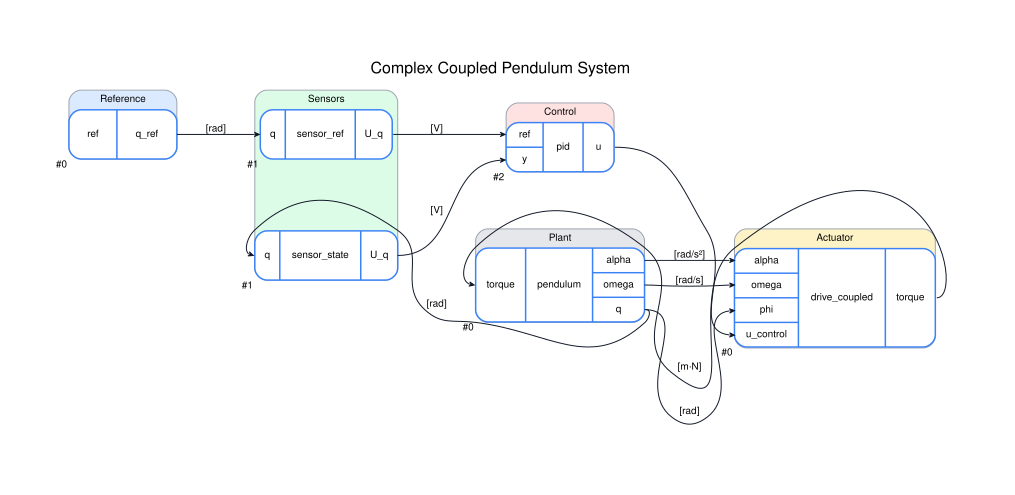

Simulating Complex Coupled System with Jacobi and dt=0.02...
LOG_SOLVER        | info    | CVODE linear multistep method CV_BDF
LOG_SOLVER        | info    | CVODE maximum integration order CV_ITER_NEWTON
LOG_SOLVER        | info    | CVODE use equidistant time grid YES
LOG_SOLVER        | info    | CVODE Using relative error tolerance 1.000000e-06
LOG_SOLVER        | info    | CVODE Using dense internal linear solver SUNLinSol_Dense.
LOG_SOLVER        | info    | CVODE Use internal dense numeric jacobian method.
LOG_SOLVER        | info    | CVODE uses internal root finding method NO
LOG_SOLVER        | info    | CVODE maximum absolut step size 0
LOG_SOLVER        | info    | CVODE initial step size is set automatically
LOG_SOLVER        | info    | CVODE maximum integration order 5
LOG_SOLVER        | info    | CVODE maximum number of nonlinear convergence failures permitted during one step 10
LOG_SOLVER        | info    | CVODE BDF stability limit detection algorithm OFF
LOG_SOLVER 

In [ ]:
c1 = Connection(src_comp=ref.name, src_port=ref.output_specs['q_ref'].name,
                dst_comp=sensor_ref.name, dst_port=sensor_ref.input_specs['q'].name)

c2 = Connection(src_comp=pendulum.name, src_port=pendulum.output_specs['q'].name,
                dst_comp=sensor_state.name, dst_port=sensor_state.input_specs['q'].name)

c3 = Connection(src_comp=sensor_ref.name, src_port=sensor_ref.output_specs['U_q'].name,
                dst_comp=pid.name, dst_port=pid.input_specs['ref'].name)

c4 = Connection(src_comp=sensor_state.name, src_port=sensor_state.output_specs['U_q'].name,
                dst_comp=pid.name, dst_port=pid.input_specs['y'].name)

c5 = Connection(src_comp=pid.name, src_port=pid.output_specs['u'].name,
                dst_comp=drive_coupled.name, dst_port=drive_coupled.input_specs['u_control'].name)

c6 = Connection(src_comp=drive_coupled.name, src_port=drive_coupled.output_specs['torque'].name,
                dst_comp=pendulum.name, dst_port=pendulum.input_specs['torque'].name)

c7a = Connection(src_comp=pendulum.name, src_port=pendulum.output_specs['q'].name,
                 dst_comp=drive_coupled.name, dst_port=drive_coupled.input_specs['phi'].name)
c7b = Connection(src_comp=pendulum.name, src_port=pendulum.output_specs['omega'].name,
                 dst_comp=drive_coupled.name, dst_port=drive_coupled.input_specs['omega'].name)
c7c = Connection(src_comp=pendulum.name, src_port=pendulum.output_specs['alpha'].name,
                 dst_comp=drive_coupled.name, dst_port=drive_coupled.input_specs['alpha'].name)

connections = [c1, c2, c3, c4, c5, c6, c7a, c7b, c7c]
components = [ref, sensor_ref, sensor_state, pid, drive_coupled, pendulum]

system = System(name="Complex Coupled Pendulum System")

for comp in components:
    system.add_component(comp)

for conn in connections:
    system.add_connection(conn)

complex_system = system
complex_system.compute_execution_order()

print("Execution Order (generations):")
for gen in complex_system.execution_order:
    print(gen)

print("\nAlgebraic Loops:")
for loop in complex_system.algebraic_loops:
    print(loop)

visualizer = SystemGraphVisualizer(complex_system)
visualizer.visualize()
visualizer.save("figures/ControlledPendulumComplex.svg")

# Run simulations for different algorithms and time steps
results = {}
res_dir = Path.cwd() / 'results/cs_complex'
res_dir.mkdir(parents=True, exist_ok=True)

for algorithm in algorithms:
    results[algorithm] = {}
    res_alg_dir = res_dir / algorithm
    res_alg_dir.mkdir(parents=True, exist_ok=True)
    for dt in dt_values:
        complex_system.history.clear()
        print(f'Simulating Complex Coupled System with {algorithm} and dt={dt}...')
        complex_system.algorithm = algorithm
        complex_system.initialize(t0, t_end)
        complex_system.run(t0, t_end, dt)
        res_file = res_alg_dir / f'complex_{algorithm}_dt_{dt:.3f}.csv'
        complex_system.history.save_csv(filepath=res_file)